In [3]:
from deepad.simulation.utils import load_results

Added 10/1000 new points. Current max distance: 5.341
Added 20/1000 new points. Current max distance: 5.088
Added 30/1000 new points. Current max distance: 4.472
Added 40/1000 new points. Current max distance: 4.372
Added 50/1000 new points. Current max distance: 4.067
Added 60/1000 new points. Current max distance: 4.015
Added 70/1000 new points. Current max distance: 3.955
Added 80/1000 new points. Current max distance: 3.876
Added 90/1000 new points. Current max distance: 3.621
Added 100/1000 new points. Current max distance: 3.796
Added 110/1000 new points. Current max distance: 3.300
Added 120/1000 new points. Current max distance: 3.387
Added 130/1000 new points. Current max distance: 3.355
Added 140/1000 new points. Current max distance: 3.205
Added 150/1000 new points. Current max distance: 3.253
Added 160/1000 new points. Current max distance: 3.236
Added 170/1000 new points. Current max distance: 3.173
Added 180/1000 new points. Current max distance: 3.095
Added 190/1000 new 

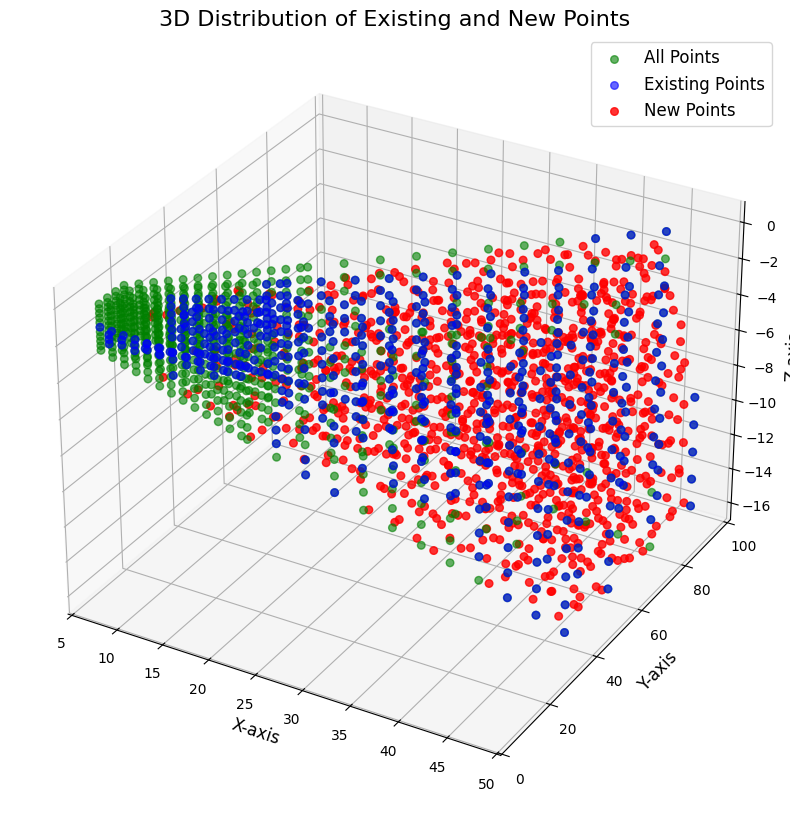

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull, Delaunay, KDTree
from mpl_toolkits.mplot3d import Axes3D
import random

def sample_points_within_hull(hull, num_samples):
    """
    Samples random points within the convex hull using rejection sampling.

    Parameters:
    - hull: scipy.spatial.ConvexHull object representing the convex hull.
    - num_samples: Number of points to sample.

    Returns:
    - points: NumPy array of shape (num_samples, 3) with sampled points.
    """
    # Get the bounding box of the hull
    min_bounds = np.min(hull.points, axis=0)
    max_bounds = np.max(hull.points, axis=0)

    points = []
    delaunay = Delaunay(hull.points[hull.vertices])

    attempts = 0
    max_attempts = num_samples * 100  # Prevent infinite loop

    while len(points) < num_samples and attempts < max_attempts:
        random_point = np.random.uniform(min_bounds, max_bounds)
        if delaunay.find_simplex(random_point) >= 0:
            points.append(random_point)
        attempts += 1

    if len(points) < num_samples:
        print(f"Warning: Only {len(points)} points were sampled within the convex hull out of requested {num_samples}.")

    return np.array(points)

def farthest_point_sampling(existing_points, hull, num_new_points, num_candidates=1000):
    """
    Performs farthest point sampling to add new points within the convex hull.

    Parameters:
    - existing_points: NumPy array of shape (M, 3) with existing data points.
    - hull: scipy.spatial.ConvexHull object representing the convex hull.
    - num_new_points: Number of new points to add.
    - num_candidates: Number of candidate points to sample at each iteration.

    Returns:
    - new_points: NumPy array of shape (num_new_points, 3) with new points.
    """
    # Initialize Delaunay triangulation for hull
    delaunay = Delaunay(hull.points[hull.vertices])

    # Initialize KDTree with existing points for efficient distance queries
    tree = KDTree(existing_points)

    new_points = []

    for i in range(num_new_points):
        # Sample candidate points within the hull
        candidates = sample_points_within_hull(hull, num_candidates)

        if candidates.size == 0:
            print("No more candidate points can be sampled within the hull.")
            break

        # For each candidate, find the distance to the nearest existing or new point
        if new_points:
            combined_points = np.vstack([existing_points, new_points])
        else:
            combined_points = existing_points

        tree_combined = KDTree(combined_points)
        distances, _ = tree_combined.query(candidates, k=1)

        # Select the candidate with the maximum minimum distance
        max_dist_idx = np.argmax(distances)
        best_candidate = candidates[max_dist_idx]
        best_distance = distances[max_dist_idx]

        new_points.append(best_candidate)

        if (i + 1) % 10 == 0 or i == num_new_points - 1:
            print(f"Added {i + 1}/{num_new_points} new points. Current max distance: {best_distance:.3f}")

    return np.array(new_points)

def visualize_points(all_points, existing_points, new_points):
    """
    Visualizes existing and new points in a 3D scatter plot.

    Parameters:
    - existing_points: NumPy array of shape (M, 3) with existing data points.
    - new_points: NumPy array of shape (N, 3) with new points.
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot existing points
    ax.scatter(all_points[:, 0], all_points[:, 1], all_points[:, 2],
               color='green', label='All Points', s=30, alpha=0.6)

    # Plot existing points
    ax.scatter(existing_points[:, 0], existing_points[:, 1], existing_points[:, 2],
               color='blue', label='Existing Points', s=30, alpha=0.6)

    # Plot new points
    if new_points.size > 0:
        ax.scatter(new_points[:, 0], new_points[:, 1], new_points[:, 2],
                   color='red', label='New Points', s=30, alpha=0.8)

    ax.set_title('3D Distribution of Existing and New Points', fontsize=16)
    ax.legend(loc='upper right', fontsize=12)
    ax.set_xlabel('X-axis', fontsize=12)
    ax.set_ylabel('Y-axis', fontsize=12)
    ax.set_zlabel('Z-axis', fontsize=12)
    plt.show()

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

data_dir = "../data/results/sim_results2/s_parameters"
all_points, freq_response = load_results(data_dir)
resonance_mask = np.any(freq_response[:, :, 1] < -20, axis = 1)
existing_points = all_points[resonance_mask]


# Compute the convex hull of existing points
hull = ConvexHull(existing_points)

# Specify the number of points to add
num_new_points = 1000

# Perform Farthest Point Sampling to add new points
new_points = farthest_point_sampling(existing_points, hull, num_new_points, num_candidates=1000)

# Visualize the existing and new points
visualize_points(all_points, existing_points, new_points)

In [10]:
new_points

array([[ 46.31028439,  44.95185821, -12.11266608],
       [ 47.01093329,  45.12593347,  -5.5481849 ],
       [ 46.23018459,  62.73491322, -10.2805808 ],
       ...,
       [ 33.78956102,  63.23383824,  -9.53117548],
       [ 16.38971072,  23.12010457,  -4.73239177],
       [ 39.17884468,  37.56557118,  -5.30370541]])